# ERA5 Reanalysis and HMS Fire and Smoke Product Data
***
Download ERA5 data from the Copernicus platform. HMS data does not need to be downloaded since it will be accessed within this script

## Import necessary libraries, modules, and packages
Additionally, install other packages that were not installed already

In [ ]:
pip install metpy

In [3]:
import xarray as xr
import numpy as np
import matplotlib as mplt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime
import pandas as pd
import datetime as datetime
from datetime import datetime, timedelta, timezone
import requests
import shapefile
import shapely
import cartopy.io.shapereader as shpreader
import cartopy.io.img_tiles as cimgt
from urllib.request import urlopen, Request
from PIL import Image
import pytz
from zipfile import ZipFile
import io
import numpy.ma as ma  # for masking arrays
import matplotlib.patches as mpatches
import metpy.calc as mpcalc
from metpy.units import units
import cartopy.io.shapereader as shpreader

In [4]:
pip install xarray cfgrib  # install engine for era5 data

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install pygrib

Note: you may need to restart the kernel to use updated packages.


## FIRST DATSET: Generate the wind, soil, and ocean datasets

In [ ]:
era5_ds = xr.open_dataset('/home/jovyan/Desktop/data/era5_data.grib', engine = 'cfgrib')
#era5_ds

In [ ]:
u10m = xr.open_dataset('/home/jovyan/Desktop/data/era5_data.grib', engine = 'cfgrib',     
            backend_kwargs={
        "filter_by_keys": {
            "shortName": "10u",         # 10-meter winds
            "typeOfLevel": "surface"    
        },
        "indexpath": ""
    }
)

v10m = xr.open_dataset('/home/jovyan/Desktop/data/era5_data.grib', engine = 'cfgrib',     
            backend_kwargs={
        "filter_by_keys": {
            "shortName": "10v",         # 10-meter winds
            "typeOfLevel": "surface"    
        },
        "indexpath": ""
    }
)

bathy_mask = era5_ds['lsm'].values # 1 = land, 0 = ocean or vice versa — check metadata

In [ ]:
u10m

In [ ]:
# formulate data arrays
t = '2025-01-08T18:00:00.000000000'
u = u10m['u10'].sel(time = t)
v = v10m['v10'].sel(time = t)

# extract date and time info
t = pd.to_datetime(t)
smoke_date_start, smoke_date_end = t.strftime('%m-%d-%Y'), t.strftime('%m-%d-%Y')
date = t.strftime('%d %b %Y')
UTC = t.strftime('%H')

# compute wind speed
wind_speed = np.sqrt(u**2 + v**2) * 2.23694

bounds = [-127, -115, 23, 36] #[-120, -115, 32, 35]
bounds = [-130, -115, 23, 36]

In [ ]:
smoke_date_start

### Combine data and plot

In [ ]:
# Plot shapefiles
smoke_date_start, smoke_date_end = t.strftime('%m-%d-%Y'), t.strftime('%m-%d-%Y')

start_datetime=datetime.strptime(smoke_date_start, "%m-%d-%Y")
end_datetime=datetime.strptime(smoke_date_end, "%m-%d-%Y")

In [ ]:
for x in range(0, 1 + (start_datetime - end_datetime).days):
    plt.close('all')
    date2grab = start_datetime + timedelta(days = x)
    obdate = date2grab.strftime("%Y%m%d")
    sm_dir = date2grab.strftime("%Y/%m/")   
    output_figure_file='./HMS_plots/HMS_NM_' + date2grab.strftime("%m.%d.%y")+'b.png'
    # Read in file with fire locations. First check the main directory, if not there, then check the archive
    smoke_dir = "https://satepsanone.nesdis.noaa.gov/pub/FIRE/web/HMS/Smoke_Polygons/Shapefile/" + sm_dir
    fire_dir = "https://satepsanone.nesdis.noaa.gov/pub/FIRE/web/HMS/Fire_Points/Text/" + sm_dir
    smoke_URL = smoke_dir + 'hms_smoke' + obdate + '.zip'
    print(smoke_URL)
    request_response = requests.head(smoke_URL)
    if (request_response.status_code == 404): 
        smoke_URL=smoke_dir + 'ARCHIVE/hms_smoke' + obdate+'.zip'
        request_response=requests.head(smoke_URL)
        if (request_response.status_code == 404): 
            print('Cannot find smoke file')
    fire_URL = fire_dir + 'hms_fire' + obdate + '.txt'
    print(fire_URL)
    request_response = requests.head(fire_URL)
    if (request_response.status_code == 404): 
        fire_URL=fire_dir+'TXT_ARCHIVE/hms'+obdate+'.txt'
        request_response=requests.head(fire_URL)
        if (request_response.status_code == 404):
            print ('Using prelim fire file')
    # Get the fire locations
    df = pd.read_csv(fire_URL)
    # Get the smoke plumes
    response=requests.get(smoke_URL)
    with ZipFile(io.BytesIO(response.content),mode='r') as zf:  
        shpfile=io.BytesIO(zf.read('hms_smoke'+obdate+'.shp'))
        dbffile=io.BytesIO(zf.read('hms_smoke'+obdate+'.dbf'))
        shxfile=io.BytesIO(zf.read('hms_smoke'+obdate+'.shx'))  
    shp_file = shapefile.Reader(shp=shpfile, shx=shxfile, dbf=dbffile)
    smoke_polys=[]
    polygons = shp_file.shapes() 
    for polygon in polygons:
        polygon = shapely.geometry.shape(polygon)
        smoke_polys.append(polygon)

    plumes = cfeature.ShapelyFeature(smoke_polys, ccrs.PlateCarree())  
    # plot the smoke and plumes
    fig = plt.figure(figsize=(8,10), facecolor = 'snow')
    rect = fig.patch
    rect.set_facecolor("white")
    m = plt.axes(projection=ccrs.PlateCarree())
    m.add_feature(cfeature.LAND)
    m.add_feature(cfeature.OCEAN, alpha=0.5)
    m.add_feature(cfeature.COASTLINE)
    m.add_feature(cfeature.BORDERS)       
    m.add_feature(cfeature.STATES)
    m.set_extent(bounds, ccrs.PlateCarree()) 

    # Shrink the number of fires to only include fires exceeding a certain threshold in fire radiative power (FRP) emitted from wildfires
    fire_threshold = 35 # Exceeding ___ FRP 
    filtered_df = df[df['        FRP'] >= fire_threshold]          # Filter the df so that where df[FRP] exceeds 100, the values will be 
    # Added to a new filtered df. THIS IS ONLY FOR THE HMS FIRE POINTS, NOT THE PLUMES
    if not filtered_df.empty:             # Plot sources if threshold is met
        #if UTC >= '18': # specific condition for jan 7 because plume polygons showing up before the event started -- probably a shapefile issue from manual illustration
            m.scatter(filtered_df['        Lon'], filtered_df['        Lat'], color='aquamarine', transform=ccrs.PlateCarree(),
              marker='v', s=20, label='HMS Fire', zorder=5)

    # Add plumes
    #if UTC >= '18': # specific condition for jan 7 because plume polygons showing up before the event started -- probably a shapefile issue from manual illustration
    m.add_feature(plumes, facecolor='gray', alpha=0.5,label='HMS Smoke',zorder=2)
    map_obdate=date2grab.strftime("%Y-%m-%d") 
    
    # plot wind speeds
    colormesh = wind_speed.plot(
        ax=m,
        cmap='magma',
        add_colorbar=False,
        transform=ccrs.PlateCarree(), 
        vmin = 5, vmax = 35
    )
    # create the colorbar
    cbar = plt.colorbar(colormesh, ax=m, orientation='horizontal', pad=0.03)
    cbar.set_label('Wind Speed (mph)', fontsize=13, fontweight = 'bold')
    cbar.ax.tick_params(labelsize=12)

    
    # plot wind direction/vectors -- only over the ocean and assume bathymetry: ocean = 1, land = 0, or elevation [m]
    bathy_mask_2d = bathy_mask[0, :, :]  # remove the first dim
    # get masked u and v values
    u_masked = ma.masked_where(bathy_mask_2d == 0, u)
    v_masked = ma.masked_where(bathy_mask_2d == 0, v)
    lon2d, lat2d = np.meshgrid(u['longitude'], u['latitude'])
    # plot wind vectors
    skip = 3  
    m.quiver(
        lon2d[::skip, ::skip], lat2d[::skip, ::skip],
        u_masked[::skip, ::skip], v_masked[::skip, ::skip],
        transform=ccrs.PlateCarree(), scale=70, width=0.003, color='seashell', zorder = 3
    )

    # plot gridlines
    gl = m.gridlines(draw_labels = True, color = 'k', alpha=0.5, linewidth=0.5, linestyle='--')
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}
    
    width_1 = -121 - (-126) #-116 - (-125)
    height_1 = 34.0 - 29.5 #36 - 30.5
    #m.add_patch(mpatches.Rectangle(xy=[-126,29.5], width = width_1, height=height_1, facecolor='none', edgecolor='white', zorder=5, linewidth = 2, transform=ccrs.PlateCarree()))
    lon_min, lon_max = -128.045, -120.517 #og
    lat_min, lat_max = 25.179, 31.164 #og

    width = lon_max - lon_min
    height = lat_max - lat_min
    m.add_patch(mpatches.Rectangle(xy=[lon_min, lat_min], width=width, height=height, facecolor='none', edgecolor='white', linewidth = 2, zorder = 6, transform=ccrs.PlateCarree()))

    m.legend(loc = 'upper left', fontsize = 10, markerscale = 2, facecolor = 'black', labelcolor = 'white')
    m.set_extent(bounds)
    m.add_feature(cfeature.BORDERS, color = 'k', linewidth = 2)
    m.add_feature(cfeature.COASTLINE, color = 'k', linewidth = 2)
    m.set_title(f"ERA5 Winds and HMS Fire and Smoke on {date} at {UTC}Z", fontsize=16, fontweight = 'bold', pad = 10)
    plt.tight_layout()
    #plt.savefig(f'/home/jovyan/Desktop/figures/ERA5 & HMS/{date}_{UTC}Z', bbox_inches = 'tight', dpi = 300)

In [ ]:
print(lon2d.shape)
print(lat2d.shape)
print(u_ocean_mask.shape)
print(v_ocean_mask.shape)

In [ ]:
# Plot shapefiles
t = '2025-01-08T18:00:00.000000000'
u = u10m['u10'].sel(time = t)
v = v10m['v10'].sel(time = t)

# extract date and time info
t = pd.to_datetime(t)
smoke_date_start, smoke_date_end = t.strftime('%m-%d-%Y'), t.strftime('%m-%d-%Y')
date = t.strftime('%d %b %Y')
UTC = t.strftime('%H')

start_datetime=datetime.strptime(smoke_date_start, "%m-%d-%Y")
end_datetime=datetime.strptime(smoke_date_end, "%m-%d-%Y")


for x in range(0, 1 + (start_datetime - end_datetime).days):
    plt.close('all')
    date2grab = start_datetime + timedelta(days = x)
    obdate = date2grab.strftime("%Y%m%d")
    sm_dir = date2grab.strftime("%Y/%m/")   
    output_figure_file='./HMS_plots/HMS_NM_' + date2grab.strftime("%m.%d.%y")+'b.png'
    # Read in file with fire locations. First check the main directory, if not there, then check the archive
    smoke_dir = "https://satepsanone.nesdis.noaa.gov/pub/FIRE/web/HMS/Smoke_Polygons/Shapefile/" + sm_dir
    fire_dir = "https://satepsanone.nesdis.noaa.gov/pub/FIRE/web/HMS/Fire_Points/Text/" + sm_dir
    smoke_URL = smoke_dir + 'hms_smoke' + obdate + '.zip'
    print(smoke_URL)
    request_response = requests.head(smoke_URL)
    if (request_response.status_code == 404): 
        smoke_URL=smoke_dir + 'ARCHIVE/hms_smoke' + obdate+'.zip'
        request_response=requests.head(smoke_URL)
        if (request_response.status_code == 404): 
            print('Cannot find smoke file')
    fire_URL = fire_dir + 'hms_fire' + obdate + '.txt'
    print(fire_URL)
    request_response = requests.head(fire_URL)
    if (request_response.status_code == 404): 
        fire_URL=fire_dir+'TXT_ARCHIVE/hms'+obdate+'.txt'
        request_response=requests.head(fire_URL)
        if (request_response.status_code == 404):
            print ('Using prelim fire file')
    # Get the fire locations
    df = pd.read_csv(fire_URL)
    # Get the smoke plumes
    response=requests.get(smoke_URL)
    with ZipFile(io.BytesIO(response.content),mode='r') as zf:  
        shpfile=io.BytesIO(zf.read('hms_smoke'+obdate+'.shp'))
        dbffile=io.BytesIO(zf.read('hms_smoke'+obdate+'.dbf'))
        shxfile=io.BytesIO(zf.read('hms_smoke'+obdate+'.shx'))  
    shp_file = shapefile.Reader(shp=shpfile, shx=shxfile, dbf=dbffile)
    smoke_polys=[]
    polygons = shp_file.shapes() 
    for polygon in polygons:
        polygon = shapely.geometry.shape(polygon)
        smoke_polys.append(polygon)

    plumes = cfeature.ShapelyFeature(smoke_polys, ccrs.PlateCarree())  
    # plot the smoke and plumes
    fig = plt.figure(figsize=(8,10), facecolor = 'snow')
    rect = fig.patch
    rect.set_facecolor("white")
    m = plt.axes(projection=ccrs.PlateCarree())
    m.add_feature(cfeature.LAND)
    m.add_feature(cfeature.OCEAN, alpha=0.5)
    m.add_feature(cfeature.COASTLINE)
    m.add_feature(cfeature.BORDERS)       
    m.add_feature(cfeature.STATES)
    m.set_extent(bounds, ccrs.PlateCarree()) 

    # Shrink the number of fires to only include fires exceeding a certain threshold in fire radiative power (FRP) emitted from wildfires
    fire_threshold = 35 # Exceeding ___ FRP 
    filtered_df = df[df['        FRP'] >= fire_threshold]          # Filter the df so that where df[FRP] exceeds 100, the values will be 
    # Added to a new filtered df. THIS IS ONLY FOR THE HMS FIRE POINTS, NOT THE PLUMES
    if not filtered_df.empty:             # Plot sources if threshold is met
        #if UTC >= '18': # specific condition for jan 7 because plume polygons showing up before the event started -- probably a shapefile issue from manual illustration
            m.scatter(filtered_df['        Lon'], filtered_df['        Lat'], color='aquamarine', transform=ccrs.PlateCarree(),
              marker='v', s=20, label='HMS Fire', zorder=5)

    # Add plumes
    #if UTC >= '18': # specific condition for jan 7 because plume polygons showing up before the event started -- probably a shapefile issue from manual illustration
    m.add_feature(plumes, facecolor='gray', alpha=0.5,label='HMS Smoke',zorder=2)
    map_obdate=date2grab.strftime("%Y-%m-%d") 
    
    # plot wind speeds
    colormesh = wind_speed.plot(
        ax=m,
        cmap='magma',
        add_colorbar=False,
        transform=ccrs.PlateCarree(), 
        vmin = 5, vmax = 35
    )
    # create the colorbar
    cbar = plt.colorbar(colormesh, ax=m, orientation='horizontal', pad=0.03)
    cbar.set_label('Wind Speed (mph)', fontsize=13, fontweight = 'bold')
    cbar.ax.tick_params(labelsize=12)

    
    # plot wind direction/vectors -- only over the ocean and assume bathymetry: ocean = 1, land = 0, or elevation [m]
    lon2d, lat2d = np.meshgrid(u['longitude'], u['latitude'])
    # plot wind vectors
    skip = 3  
    m.quiver(
        lon2d[::skip, ::skip], lat2d[::skip, ::skip],
        u[::skip, ::skip], v[::skip, ::skip],
        transform=ccrs.PlateCarree(), scale=70, width=0.003, color='seashell', zorder = 3
    )

    # plot gridlines
    gl = m.gridlines(draw_labels = True, color = 'k', alpha=0.5, linewidth=0.5, linestyle='--')
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}



    width_1 = -118 - (-119.5) #-116 - (-125)
    height_1 = 34.1 - 33.4 #36 - 30.5
    m.add_patch(mpatches.Rectangle(xy=[-119.5,33.4], width = width_1, height=height_1, facecolor='none', edgecolor='white', zorder=5, linewidth = 2, transform=ccrs.PlateCarree()))
    
    lon_min, lon_max = -126.4262, -119.4634 # 1: -128.045, -120.517
    lat_min, lat_max = 25.0803, 31.5100 # 1: 25.179, 31.164
    width = lon_max - lon_min
    height = lat_max - lat_min
    m.add_patch(mpatches.Rectangle(xy=[lon_min, lat_min], width=width, height=height, facecolor='none', edgecolor='navy', linewidth = 2, zorder = 6, transform=ccrs.PlateCarree()))



    
    m.legend(loc = 'upper left', fontsize = 10, markerscale = 2, facecolor = 'black', labelcolor = 'white')
    m.set_extent(bounds)
    m.add_feature(cfeature.BORDERS, color = 'k', linewidth = 2)
    m.add_feature(cfeature.COASTLINE, color = 'k', linewidth = 2)
    m.set_title(f"ERA5 Winds and HMS Fire and Smoke on {date} at {UTC}Z", fontsize=16, fontweight = 'bold', pad = 10)
    plt.tight_layout()
    #plt.savefig(f'/home/jovyan/Desktop/figures/ERA5 & HMS/{date}_{UTC}Z', bbox_inches = 'tight', dpi = 300)

# Additional code: Separated pieces

# NEW DATASET: Plotting wind and RH -- 0.1 = ~9 km data

In [915]:
#era5_ds = xr.open_dataset('/home/jovyan/Desktop/data/newest era5/era5_hourly_data.grib', engine = 'cfgrib')

u10m = xr.open_dataset('/home/jovyan/Desktop/data/newest era5/era5_hourly_data.grib', engine = 'cfgrib',     
            backend_kwargs={
        "filter_by_keys": {
            "shortName": "10u",         # 10-meter winds
            "typeOfLevel": "surface"    
        },
        "indexpath": ""
    }
)

v10m = xr.open_dataset('/home/jovyan/Desktop/data/newest era5/era5_hourly_data.grib', engine = 'cfgrib',     
            backend_kwargs={
        "filter_by_keys": {
            "shortName": "10v",         # 10-meter winds
            "typeOfLevel": "surface"    
        },
        "indexpath": ""
    }
)
# 2m dewpoint temperature, 2m temperature, Soil temperature level 1, Volumetric soil water layer 1, 10m u-component of wind, 10m v-component of wind, Surface pressure, Land-sea mask

td = xr.open_dataset('/home/jovyan/Desktop/data/newest era5/era5_hourly_data.grib', engine = 'cfgrib',     
            backend_kwargs={
        "filter_by_keys": {
            "shortName": "2d",         # 10-meter winds
            "typeOfLevel": "surface"    
        },
        "indexpath": ""
    }
)

t = xr.open_dataset('/home/jovyan/Desktop/data/newest era5/era5_hourly_data.grib', engine = 'cfgrib',     
            backend_kwargs={
        "filter_by_keys": {
            "shortName": "2t",        
            "typeOfLevel": "surface"    
        },
        "indexpath": ""
    }
)
'''
swvl1 = xr.open_dataset('/home/jovyan/Desktop/data/newest era5/era5_hourly_data.grib', engine = 'cfgrib',     
            backend_kwargs={
        "filter_by_keys": {
            "shortName": "swvl1",       
            "typeOfLevel": "surface"    
        },
        "indexpath": ""
    }
)
'''
stl1 = xr.open_dataset('/home/jovyan/Desktop/data/newest era5/era5_hourly_data.grib', engine = 'cfgrib',     
            backend_kwargs={
        "filter_by_keys": {
            "shortName": "stl1",        
            "typeOfLevel": "surface"    
        },
        "indexpath": ""
    }
)


sp = xr.open_dataset('/home/jovyan/Desktop/data/newest era5/era5_hourly_data.grib', engine = 'cfgrib',     
            backend_kwargs={
        "filter_by_keys": {
            "shortName": "sp",        
            "typeOfLevel": "surface"    
        },
        "indexpath": ""
    }
)

#bathy_mask = era5_ds['lsm'].values # 1 = land, 0 = ocean or vice versa — check metadata

/srv/conda/envs/notebook/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/srv/conda/envs/notebook/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/srv/conda/envs/notebook/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names 

## WIND

In [10]:
u10m

<xarray.Dataset> Size: 112MB
Dimensions:     (time: 32, step: 24, latitude: 201, longitude: 181)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 256B 2024-12-31 2025-01-01 ... 2025-01-31
  * step        (step) timedelta64[ns] 192B 01:00:00 ... 1 days 00:00:00
    surface     float64 8B ...
  * latitude    (latitude) float64 2kB 43.0 42.9 42.8 42.7 ... 23.2 23.1 23.0
  * longitude   (longitude) float64 1kB -130.0 -129.9 -129.8 ... -112.1 -112.0
    valid_time  (time, step) datetime64[ns] 6kB ...
Data variables:
    u10         (time, step, latitude, longitude) float32 112MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-25T21:37 GRIB to CDM+CF via cfgrib-0.9.1...

In [11]:
u10m['step'] = u10m['step'].values / 3600000000000 # divide by 3,600,000,000,000 since the original data is in ns
v10m['step'] = v10m['step'].values / 3600000000000 # divide by 3,600,000,000,000 since the original data is in ns
sp['step'] = sp['step'].values / 3600000000000 # divide by 3,600,000,000,000 since the original data is in ns
t['step'] = t['step'].values / 3600000000000 # divide by 3,600,000,000,000 since the original data is in ns
td['step'] = td['step'].values / 3600000000000 # divide by 3,600,000,000,000 since the original data is in ns

In [12]:
u10m

<xarray.Dataset> Size: 112MB
Dimensions:     (time: 32, step: 24, latitude: 201, longitude: 181)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 256B 2024-12-31 2025-01-01 ... 2025-01-31
  * step        (step) timedelta64[ns] 192B 00:00:00.000000001 ... 00:00:00.0...
    surface     float64 8B ...
  * latitude    (latitude) float64 2kB 43.0 42.9 42.8 42.7 ... 23.2 23.1 23.0
  * longitude   (longitude) float64 1kB -130.0 -129.9 -129.8 ... -112.1 -112.0
    valid_time  (time, step) datetime64[ns] 6kB ...
Data variables:
    u10         (time, step, latitude, longitude) float32 112MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-25T21:37 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
# time for the day you want to look into
t = '2025-01-12T00:00:00.000000000'
# idx for step number declaration
idx = 17         # 0 = hour 1/ index = 1
    # IMPORTANT: so the start time is the time. the step is 1 hour, 2 hour, etc. after that 0Z time


# formulate data arrays
u = u10m['u10'].sel(time=t).isel(step=idx) # isel is making this off beat, so hour 1 = 0  indexing wise
v = v10m['v10'].sel(time=t).isel(step=idx)

# extract date and time info
t = pd.to_datetime(t)
smoke_date_start, smoke_date_end = t.strftime('%m-%d-%Y'), t.strftime('%m-%d-%Y')
date = t.strftime('%d %b %Y')
next_date = (t + pd.Timedelta(days=1)).strftime('%d %b %Y')

# extract hourly data
z = idx + 1 # needs to be + 1 because index 0 is 1 hour past 00Z in the time
print(z)
if z < 10:
    UTC = f'0{z}'
if z == 24:
    UTC = '00'
if z >= 10:
    UTC = f'{z}'
print(UTC)
# compute wind speed
wind_speed = np.sqrt(u**2 + v**2) * 2.23694
bounds = [-130, -113, 23, 37]

In [ ]:
# Plot shapefiles
smoke_date_start, smoke_date_end = t.strftime('%m-%d-%Y'), t.strftime('%m-%d-%Y')

start_datetime=datetime.strptime(smoke_date_start, "%m-%d-%Y")
end_datetime=datetime.strptime(smoke_date_end, "%m-%d-%Y")

In [ ]:
for x in range(0, 1 + (start_datetime - end_datetime).days):
    plt.close('all')
    date2grab = start_datetime + timedelta(days = x)
    obdate = date2grab.strftime("%Y%m%d")
    sm_dir = date2grab.strftime("%Y/%m/")   
    output_figure_file='./HMS_plots/HMS_NM_' + date2grab.strftime("%m.%d.%y")+'b.png'
    # Read in file with fire locations. First check the main directory, if not there, then check the archive
    smoke_dir = "https://satepsanone.nesdis.noaa.gov/pub/FIRE/web/HMS/Smoke_Polygons/Shapefile/" + sm_dir
    fire_dir = "https://satepsanone.nesdis.noaa.gov/pub/FIRE/web/HMS/Fire_Points/Text/" + sm_dir
    smoke_URL = smoke_dir + 'hms_smoke' + obdate + '.zip'
    print(smoke_URL)
    request_response = requests.head(smoke_URL)
    if (request_response.status_code == 404): 
        smoke_URL=smoke_dir + 'ARCHIVE/hms_smoke' + obdate+'.zip'
        request_response=requests.head(smoke_URL)
        if (request_response.status_code == 404): 
            print('Cannot find smoke file')
    fire_URL = fire_dir + 'hms_fire' + obdate + '.txt'
    print(fire_URL)
    request_response = requests.head(fire_URL)
    if (request_response.status_code == 404): 
        fire_URL=fire_dir+'TXT_ARCHIVE/hms'+obdate+'.txt'
        request_response=requests.head(fire_URL)
        if (request_response.status_code == 404):
            print ('Using prelim fire file')
    # Get the fire locations
    df = pd.read_csv(fire_URL)
    # Get the smoke plumes
    response=requests.get(smoke_URL)
    with ZipFile(io.BytesIO(response.content),mode='r') as zf:  
        shpfile=io.BytesIO(zf.read('hms_smoke'+obdate+'.shp'))
        dbffile=io.BytesIO(zf.read('hms_smoke'+obdate+'.dbf'))
        shxfile=io.BytesIO(zf.read('hms_smoke'+obdate+'.shx'))  
    shp_file = shapefile.Reader(shp=shpfile, shx=shxfile, dbf=dbffile)
    smoke_polys=[]
    polygons = shp_file.shapes() 
    for polygon in polygons:
        polygon = shapely.geometry.shape(polygon)
        smoke_polys.append(polygon)

    plumes = cfeature.ShapelyFeature(smoke_polys, ccrs.PlateCarree())  
    # plot the smoke and plumes
    fig = plt.figure(figsize=(8,10), facecolor = 'snow')
    rect = fig.patch
    rect.set_facecolor("white")
    m = plt.axes(projection=ccrs.PlateCarree())
    m.add_feature(cfeature.LAND)
    m.add_feature(cfeature.OCEAN, alpha=0.5)
    m.add_feature(cfeature.COASTLINE)
    m.add_feature(cfeature.BORDERS)       
    m.add_feature(cfeature.STATES)
    m.set_extent(bounds, ccrs.PlateCarree()) 

    # Shrink the number of fires to only include fires exceeding a certain threshold in fire radiative power (FRP) emitted from wildfires
    fire_threshold = 35 # Exceeding ___ FRP 
    filtered_df = df[df['        FRP'] >= fire_threshold]          # Filter the df so that where df[FRP] exceeds 100, the values will be 
    # Added to a new filtered df. THIS IS ONLY FOR THE HMS FIRE POINTS, NOT THE PLUMES
    if not filtered_df.empty:             # Plot sources if threshold is met
        #if UTC >= '18': # specific condition for jan 7 because plume polygons showing up before the event started -- probably a shapefile issue from manual illustration
            m.scatter(filtered_df['        Lon'], filtered_df['        Lat'], color='aquamarine', transform=ccrs.PlateCarree(),
              marker='v', s=20, label='HMS Fire', zorder=5)

    # Add plumes
    #if UTC >= '18': # specific condition for jan 7 because plume polygons showing up before the event started -- probably a shapefile issue from manual illustration
    m.add_feature(plumes, facecolor='gray', alpha=0.5,label='HMS Smoke',zorder=2)
    map_obdate=date2grab.strftime("%Y-%m-%d") 
    
    # plot wind speeds
    colormesh = wind_speed.plot(
        ax=m,
        cmap='magma',
        add_colorbar=False,
        transform=ccrs.PlateCarree(), 
        vmin = 5, vmax = 35
    )
    # create the colorbar
    cbar = plt.colorbar(colormesh, ax=m, orientation='horizontal', pad=0.03)
    cbar.set_label('Wind Speed (mph)', fontsize=13, fontweight = 'bold')
    cbar.ax.tick_params(labelsize=12)


    lon2d, lat2d = np.meshgrid(u['longitude'], u['latitude'])
    # plot wind vectors
    skip = 6
    m.quiver(
        lon2d[::skip, ::skip], lat2d[::skip, ::skip],
        u[::skip, ::skip], v[::skip, ::skip],
        transform=ccrs.PlateCarree(), scale=70, width=0.003, color='seashell', zorder = 3
    )

    # plot gridlines
    gl = m.gridlines(draw_labels = True, color = 'k', alpha=0.5, linewidth=0.5, linestyle='--')
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}
    
    width_1 = -121 - (-126) #-116 - (-125)
    height_1 = 34.0 - 29.5 #36 - 30.5
    #m.add_patch(mpatches.Rectangle(xy=[-126,29.5], width = width_1, height=height_1, facecolor='none', edgecolor='white', zorder=5, linewidth = 2, transform=ccrs.PlateCarree()))
    lon_min, lon_max = -128.045, -120.517 #og
    lat_min, lat_max = 25.179, 31.164 #og

    width = lon_max - lon_min
    height = lat_max - lat_min
    #m.add_patch(mpatches.Rectangle(xy=[lon_min, lat_min], width=width, height=height, facecolor='none', edgecolor='black', linewidth = 2, zorder = 6, transform=ccrs.PlateCarree()))

    m.legend(loc = 'upper left', fontsize = 10, markerscale = 2, facecolor = 'black', labelcolor = 'white')
    m.set_extent(bounds)
    m.add_feature(cfeature.BORDERS, color = 'k', linewidth = 2)
    m.add_feature(cfeature.COASTLINE, color = 'k', linewidth = 2)
    m.add_feature(cfeature.OCEAN, color = 'lavender', linewidth = 2, alpha = 0.3)

    m.set_title(f"ERA5 Winds and HMS Fire and Smoke on {date} at {UTC}Z", fontsize=16, fontweight = 'bold', pad = 10)
    plt.tight_layout()
    if idx == 23:
            m.set_title(f"ERA5 Winds and HMS Fire and Smoke on {next_date} at 00Z", fontsize=16, fontweight = 'bold', pad = 10)
            plt.savefig(f'/home/jovyan/Desktop/figures/ERA newest/{next_date}_00Z', bbox_inches = 'tight', dpi = 300)
    else:
        plt.savefig(f'/home/jovyan/Desktop/figures/ERA newest/{date}_{UTC}Z', bbox_inches = 'tight', dpi = 300)

## RH

In [917]:
td = xr.open_dataset('/home/jovyan/Desktop/data/newest era5/era5_hourly_data.grib', engine = 'cfgrib',     
            backend_kwargs={
        "filter_by_keys": {
            "shortName": "2d",         # 10-meter winds
            "typeOfLevel": "surface"    
        },
        "indexpath": ""
    }
)

t = xr.open_dataset('/home/jovyan/Desktop/data/newest era5/era5_hourly_data.grib', engine = 'cfgrib',     
            backend_kwargs={
        "filter_by_keys": {
            "shortName": "2t",        
            "typeOfLevel": "surface"    
        },
        "indexpath": ""
    }
)

/srv/conda/envs/notebook/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/srv/conda/envs/notebook/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [918]:
t['step'] = t['step'].values / 3600000000000 # divide by 3,600,000,000,000 since the original data is in ns
td['step'] = td['step'].values / 3600000000000 # divide by 3,600,000,000,000 since the original data is in ns

In [919]:
t = t['t2m'] * units.kelvin
td = td['d2m'] * units.kelvin
#td

In [920]:
t = t.metpy.convert_units('degC')
td = td.metpy.convert_units('degC')
#td

In [921]:
# compute rh
rh = mpcalc.relative_humidity_from_dewpoint(t,td)
rh = rh*100
#rh

In [1486]:
# time for the day you want to look into
time = '2025-01-06T00:00:00.000000000'
# idx for step number declaration
idx = 23        # 0 = hour 1/ index = 1
    # IMPORTANT: so the start time is the time. the step is 1 hour, 2 hour, etc. after that 0Z time

In [1487]:
# formulate data arrays
rel_hum = rh.sel(time=time).isel(step=idx) # isel is making this off beat, so hour 1 = 0  indexing wise

In [1488]:
# extract date and time info
time = pd.to_datetime(time)
smoke_date_start, smoke_date_end = time.strftime('%m-%d-%Y'), time.strftime('%m-%d-%Y')
date = time.strftime('%d %b %Y')
next_date = (time + pd.Timedelta(days=1)).strftime('%d %b %Y')

In [1489]:
# extract hourly data
z = idx + 1 # needs to be + 1 because index 0 is 1 hour past 00Z in the time
print(z)
if z < 10:
    UTC = f'0{z}'
if z == 24:
    UTC = '00'
if z >= 10:
    UTC = f'{z}'
print(UTC)
bounds = [-121, -116.5, 32.5, 35.2]

24
24


/srv/conda/envs/notebook/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


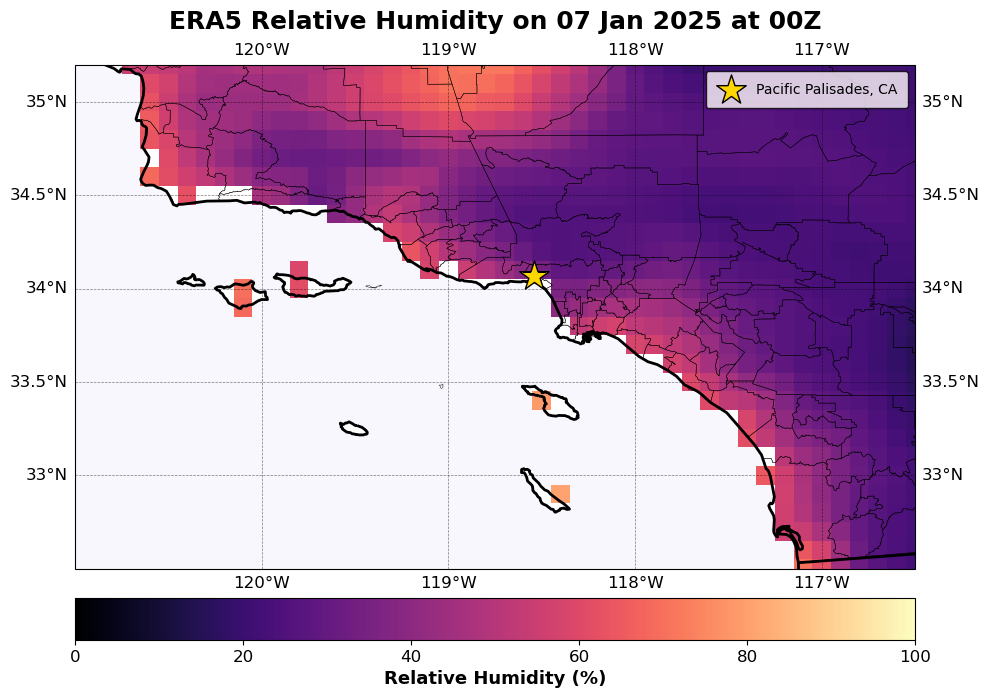

In [1490]:
fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.PlateCarree())

# plot gridlines
gl = ax.gridlines(draw_labels = True, color = 'k', alpha=0.5, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

reader = shpreader.Reader('/home/jovyan/Desktop/data/shapefile data/cb_2024_06_cousub_500k.shp')
ax.add_geometries(reader.geometries(), crs=ccrs.PlateCarree(),facecolor='none', edgecolor='k', linewidth=0.3)
ax.scatter(-118.54, 34.07, marker='*', s=500, color='gold', edgecolor='k', zorder=10, label = 'Pacific Palisades, CA')

# plot wind speeds
colormesh = rel_hum.plot(
    ax=ax,
    cmap='magma',
    add_colorbar=False,
    transform=ccrs.PlateCarree(), 
    vmin = 0, vmax = 100
)
# create the colorbar
cbar = plt.colorbar(colormesh, ax=ax, orientation='horizontal', pad=0.03)
cbar.set_label('Relative Humidity (%)', fontsize=13, fontweight = 'bold')
cbar.ax.tick_params(labelsize=12)

ax.set_extent(bounds)
ax.add_feature(cfeature.BORDERS, color = 'k', linewidth = 2)
ax.add_feature(cfeature.COASTLINE, color = 'k', linewidth = 2)
ax.add_feature(cfeature.OCEAN, color = 'lavender', linewidth = 2, alpha = 0.3)

legend = ax.legend(loc = 'upper right', facecolor = 'snow', edgecolor ='k', borderpad = 0.8)

ax.set_title(f"ERA5 Relative Humidity on {date} at {UTC}Z", fontsize=18, fontweight = 'bold', pad = 10)
plt.tight_layout()
if idx == 23:
        ax.set_title(f"ERA5 Relative Humidity on {next_date} at 00Z", fontsize=18, fontweight = 'bold', pad = 10)
        plt.savefig(f'/home/jovyan/Desktop/figures/ERA5 rh/rh_{next_date}_00Z', bbox_inches = 'tight', dpi = 300)
else:
    plt.savefig(f'/home/jovyan/Desktop/figures/ERA5 rh/rh_{date}_{UTC}Z', bbox_inches = 'tight', dpi = 300)